# Notebook 2: Persistent Homology

## Persistence Diagrams and Persistence Barcodes

This notebook introduces **persistent homology** as a practical tool for determining the **shape of data** from point clouds. You will learn how to construct and interpret **persistence diagrams** and **persistence barcodes** using three Python libraries:

1. **Gudhi**
2. **Ripser**
3. **Giotto-TDA**

The central question of the notebook is:

> Given a point cloud, can we infer whether the data looks like disconnected clusters, a circle, or multiple loops by analyzing its persistence diagram and barcode?

We will focus on how topological features:
- **are born** at a filtration value
- **persist** across scales
- **die** when the complex becomes too connected

---

**Prerequisites:** Filtrations of simplicial complexes (Notebook 1) and the introductory theory from Lecture 17.

**Author:** Alejandro Ucan-Puc  
**Last Updated:** March 2026

In [2]:
import sys
!{sys.executable} -m pip install ripser persim giotto-tda

  Using cached ripser-0.6.14-cp311-cp311-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached persim-0.3.8-py3-none-any.whl.metadata (3.8 kB)
  Using cached cython-3.2.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (7.5 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached hopcroftkarp-1.2.5-py2.py3-none-any.whl
  Using cached wrapt-2.1.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (7.4 kB)
Using cached ripser-0.6.14-cp311-cp311-macosx_11_0_arm64.whl (169 kB)
Using cached persim-0.3.8-py3-none-any.whl (48 kB)
Using cached cython-3.2.4-cp311-cp311-macosx_11_0_arm64.whl (3.0 MB)
Using cached deprecated-1.3.1-py2.py3-none-any.whl (11 kB)
Using cached wrapt-2.1.2-cp311-cp311-macosx_11_0_arm64.whl (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [ripser]2m2/6 [Cython]


In [3]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tadasets
import gudhi as gd
from ripser import ripser
from persim import plot_diagrams, bottleneck
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram

warnings.filterwarnings("ignore")
np.random.seed(42)


def diagram_sizes(diagrams):
    return ", ".join([f"|H_{i}|={len(dgm)}" for i, dgm in enumerate(diagrams)])


def persistence_lengths(dgm):
    if len(dgm) == 0:
        return np.array([])
    finite = dgm[np.isfinite(dgm[:, 1])]
    if len(finite) == 0:
        return np.array([])
    return finite[:, 1] - finite[:, 0]


def count_long_features(dgm, min_persistence=0.4):
    lengths = persistence_lengths(dgm)
    return int(np.sum(lengths > min_persistence))

## 1. Visual Intuition: What Does Persistent Homology Measure?

Persistent homology studies how topological features evolve along a filtration:

- **$H_0$** detects connected components
- **$H_1$** detects loops or 1-dimensional holes
- **$H_2$** detects voids in 3D data

A feature is recorded by a pair:
$$ (\text{birth}, \text{death}) $$
where:
- **birth** = scale where the feature appears
- **death** = scale where the feature disappears

Long-lived features are usually interpreted as **signal**, while short-lived features are often **noise**.

### Interactive intuition links

These examples are worth opening while reading the notebook:

- Connected components: https://gjkoplik.github.io/pers-hom-examples/0d_pers_2d_data_widget.html
- One-dimensional holes: https://gjkoplik.github.io/pers-hom-examples/1d_pers_2d_data_widget.html
- Both together: https://www.geogebra.org/m/muwz8vgx

In [4]:
# Three point clouds with different shapes
n_points = 120

# 1. Three disconnected clusters
X1 = np.random.multivariate_normal([0, 0], [[0.25, 0], [0, 0.25]], size=40)
X2 = np.random.multivariate_normal([4.5, 0], [[0.30, 0], [0, 0.20]], size=40)
X3 = np.random.multivariate_normal([0, 5], [[0.25, 0], [0, 0.25]], size=40)
cloud_clusters = np.vstack([X1, X2, X3])

# 2. One noisy circl (d=1, n=n_points, r=2, noise=0.15)

# 3. Two noisy circles
circle_a = tadasets.dsphere(d=1, n=n_points // 2, r=1.3, noise=0.08) + np.array([-2.0, 0.0])
circle_b = tadasets.dsphere(d=1, n=n_points // 2, r=1.3, noise=0.08) + np.array([ 2.0, 0.0])
cloud_two_circles = np.vstack([circle_a, circle_b])

datasets = {
    "Three clusters": cloud_clusters,
    "One noisy circle": cloud_circle,
    "Two noisy circles": cloud_two_circles,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (title, data) in zip(axes, datasets.items()):
    ax.scatter(data[:, 0], data[:, 1], s=12, c="black")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

plt.suptitle("Three point clouds, three different shapes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Question for the student:")
print("- Which dataset should have several H0 features?")
print("- Which one should have one persistent H1 feature?")
print("- Which one should have two persistent H1 features?")

NameError: name 'cloud_circle' is not defined

In [33]:
import pandas as pd
df=pd.DataFrame(data=cloud_clusters[1:,1:],
                index=data[1:,0],
                columns=data[0,1:])

df.info()
df

<class 'pandas.core.frame.DataFrame'>
Index: 119 entries, -3.2224521292622974 to 1.148825617446454
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   0.8915913244863838  119 non-null    float64
dtypes: float64(1)
memory usage: 1.9 KB


,0.891591
-3.222452,0.761515
-2.165657,-0.117068
-1.353672,0.383717
-3.012369,0.271280
-0.742557,-0.232865
...,...
3.234086,5.108229
3.134444,4.674200
3.195710,5.316960
3.191545,5.093227


## 2. Persistence Diagrams and Barcodes

There are two standard ways to visualize persistence:

### Persistence Diagram
Each feature is represented by a point $(b, d)$ in the plane.

- Points near the diagonal $d=b$ correspond to short-lived features
- Points far from the diagonal correspond to persistent topological structure

### Persistence Barcode
Each feature is represented by a horizontal interval $[b, d)$.

- Long bars suggest meaningful features
- Short bars usually suggest noise

In practice:
- Many long bars in **$H_0$** indicate multiple clusters
- One long bar in **$H_1$** often indicates one loop
- Two long bars in **$H_1$** suggest two loops

In [16]:
# Example with GUDHI on the three-cluster dataset
rips_clusters = gd.RipsComplex(points=cloud_clusters, max_edge_length=3.0)
st_clusters = rips_clusters.create_simplex_tree(max_dimension=2)
persistence_clusters = st_clusters.persistence()

print("GUDHI example on the three-cluster dataset")
print(f"Simplex tree dimension: {st_clusters.dimension()}")
print(f"Number of simplices: {st_clusters.num_simplices()}")
print(f"Number of vertices: {st_clusters.num_vertices()}")
print("\nFirst persistence pairs:")
for pair in persistence_clusters[:10]:
    print(pair)

GUDHI example on the three-cluster dataset
Simplex tree dimension: 2
Number of simplices: 32127
Number of vertices: 120

First persistence pairs:
(1, (0.40713680866154883, 0.5909826734357289))
(1, (0.4150490105177895, 0.5578869085780547))
(1, (0.3106498386343282, 0.4442174353492856))
(1, (0.3598174527764171, 0.48550212204562276))
(1, (0.28835313140712215, 0.3963795354594535))
(1, (0.24181745421465536, 0.3415492736816119))
(1, (0.28164896913140436, 0.3440692866241957))
(1, (0.3210699448395224, 0.3767380641354692))
(1, (0.25932310938435, 0.3087066045877132))
(1, (0.3687461884081223, 0.4166293020686399))


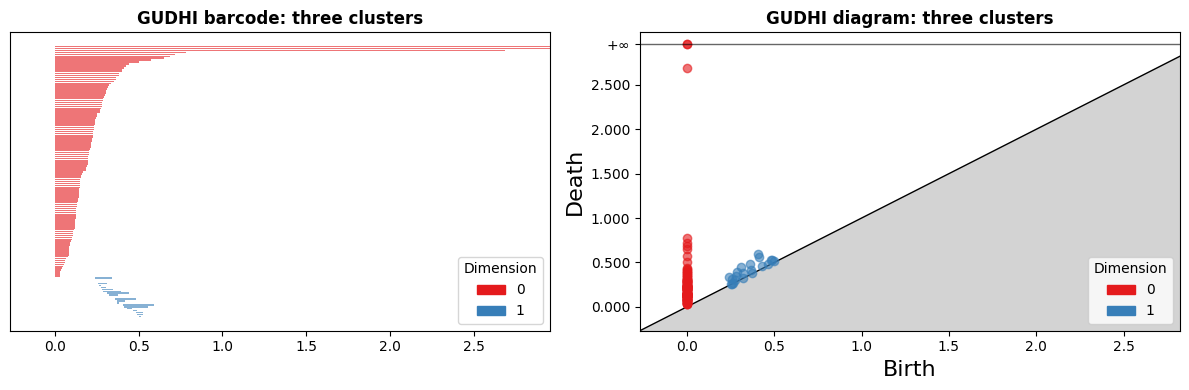

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gd.plot_persistence_barcode(persistence_clusters, axes=axes[0])
axes[0].set_title("GUDHI barcode: three clusters", fontweight="bold")
gd.plot_persistence_diagram(persistence_clusters, axes=axes[1])
axes[1].set_title("GUDHI diagram: three clusters", fontweight="bold")
plt.tight_layout()
plt.show()

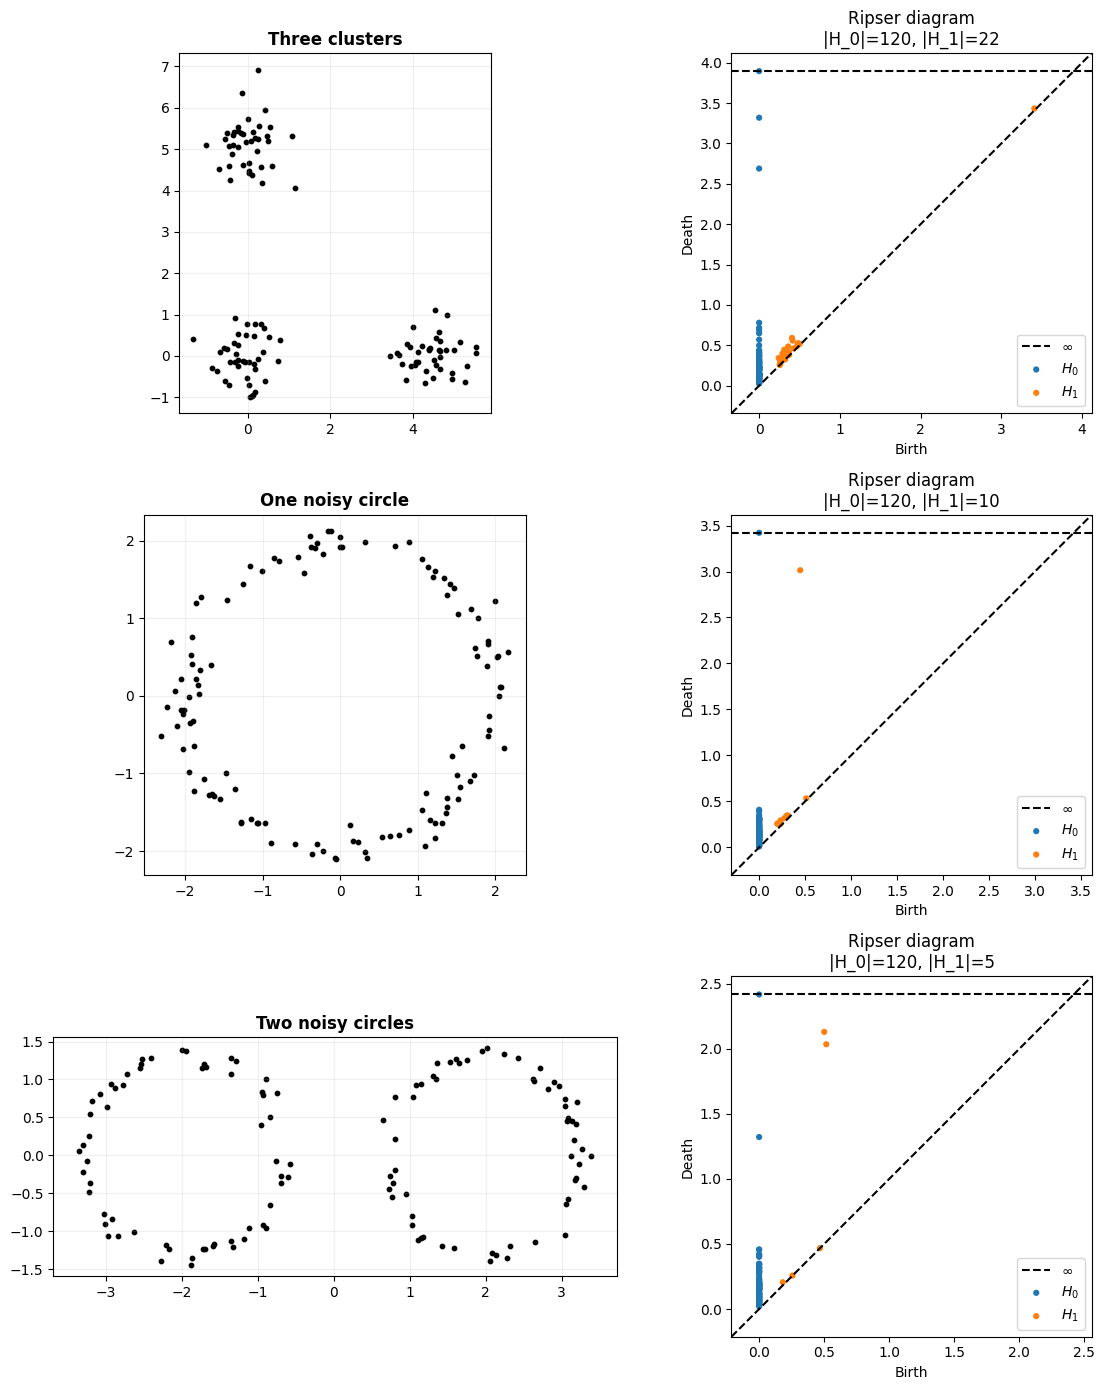

Interpretation:
- Three clusters: several H0 points away from the diagonal
- One noisy circle: one dominant H1 point
- Two noisy circles: two dominant H1 points


In [18]:
# Compare the three shapes with Ripser
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
ripser_results = {}

for row, (title, data) in enumerate(datasets.items()):
    dgms = ripser(data, maxdim=1)["dgms"]
    ripser_results[title] = dgms

    axes[row, 0].scatter(data[:, 0], data[:, 1], s=10, c="black")
    axes[row, 0].set_title(title, fontsize=12, fontweight="bold")
    axes[row, 0].set_aspect("equal")
    axes[row, 0].grid(True, alpha=0.2)

    plot_diagrams(dgms, ax=axes[row, 1], show=False,
                  title=f"Ripser diagram\n{diagram_sizes(dgms)}")

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Three clusters: several H0 points away from the diagonal")
print("- One noisy circle: one dominant H1 point")
print("- Two noisy circles: two dominant H1 points")

In [19]:
# Quantify the interpretation of the Ripser diagrams
for title, dgms in ripser_results.items():
    h0_long = count_long_features(dgms[0], min_persistence=0.35)
    h1_long = count_long_features(dgms[1], min_persistence=0.35)
    print(f"{title:18s} | long H0 features: {h0_long:2d} | long H1 features: {h1_long:2d}")

print("\nThis is not a theorem-based classifier, but it gives a useful heuristic:")
print("many long H0 bars -> disconnected clusters")
print("one long H1 bar  -> one loop")
print("two long H1 bars -> two loops")

Three clusters     | long H0 features: 18 | long H1 features:  0
One noisy circle   | long H0 features:  3 | long H1 features:  1
Two noisy circles  | long H0 features:  7 | long H1 features:  2

This is not a theorem-based classifier, but it gives a useful heuristic:
many long H0 bars -> disconnected clusters
one long H1 bar  -> one loop
two long H1 bars -> two loops


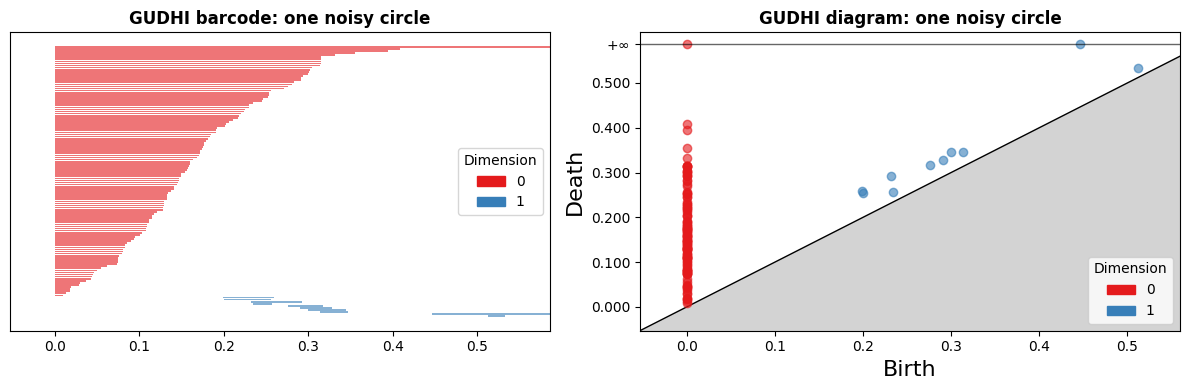

Look for one long bar / one point far from the diagonal in H1.


In [20]:
# GUDHI on the noisy circle: barcode and diagram
rips_circle = gd.RipsComplex(points=cloud_circle, max_edge_length=2.5)
st_circle = rips_circle.create_simplex_tree(max_dimension=2)
persistence_circle = st_circle.persistence()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gd.plot_persistence_barcode(persistence_circle, axes=axes[0])
axes[0].set_title("GUDHI barcode: one noisy circle", fontweight="bold")
gd.plot_persistence_diagram(persistence_circle, axes=axes[1])
axes[1].set_title("GUDHI diagram: one noisy circle", fontweight="bold")
plt.tight_layout()
plt.show()

print("Look for one long bar / one point far from the diagonal in H1.")

## 3. Gudhi, Ripser, and Giotto-TDA

Each library gives access to persistent homology, but with slightly different strengths:

- **Gudhi** is excellent for direct access to filtrations and simplex trees
- **Ripser** is very fast for Vietoris–Rips persistent homology on point clouds and distance matrices
- **Giotto-TDA** provides a scikit-learn style pipeline for topological machine learning

The next cells use **Giotto-TDA** to compute persistence diagrams for several point clouds in a batch.

In [21]:
# Giotto-TDA computes persistence on batches of point clouds.
# We use three datasets with the same number of points to build a small batch.

gtda_input = np.stack([
    cloud_clusters[:n_points],
    cloud_circle,
    cloud_two_circles,
])

vr = VietorisRipsPersistence(metric="euclidean", homology_dimensions=[0, 1], n_jobs=1)
gtda_diagrams = vr.fit_transform(gtda_input)

print("Giotto-TDA output shape:", gtda_diagrams.shape)
print("The last coordinate stores the homology dimension of each point in the diagram.")

Giotto-TDA output shape: (3, 141, 3)
The last coordinate stores the homology dimension of each point in the diagram.


In [22]:
# Visualize the Giotto-TDA diagrams one by one
labels_gtda = ["Three clusters", "One noisy circle", "Two noisy circles"]

for idx, label in enumerate(labels_gtda):
    fig = plot_diagram(gtda_diagrams[idx])
    fig.update_layout(title=f"Giotto-TDA diagram: {label}")
    fig.show()

In [23]:
# Compare Ripser and GUDHI on the same noisy circle dataset
# Recompute the GUDHI persistence here so the cell is self-contained.
rips_circle = gd.RipsComplex(points=cloud_circle, max_edge_length=2.5)
st_circle_compare = rips_circle.create_simplex_tree(max_dimension=2)
persistence_circle_compare = st_circle_compare.persistence()
ripser_circle = ripser(cloud_circle, maxdim=1)["dgms"]

gudhi_h1 = np.array([
    (birth, death)
    for dim, (birth, death) in persistence_circle_compare
    if dim == 1 and np.isfinite(death)
])
ripser_h1 = ripser_circle[1]

print("Number of H1 generators")
print("GUDHI :", len(gudhi_h1))
print("Ripser:", len(ripser_h1))

if len(gudhi_h1) > 0 and len(ripser_h1) > 0:
    print("Approximate bottleneck distance between H1 diagrams:", bottleneck(gudhi_h1, ripser_h1))
else:
    print("Could not compare H1 diagrams because one of them is empty.")

Number of H1 generators
GUDHI : 9
Ripser: 10
Approximate bottleneck distance between H1 diagrams: 1.283732995390892


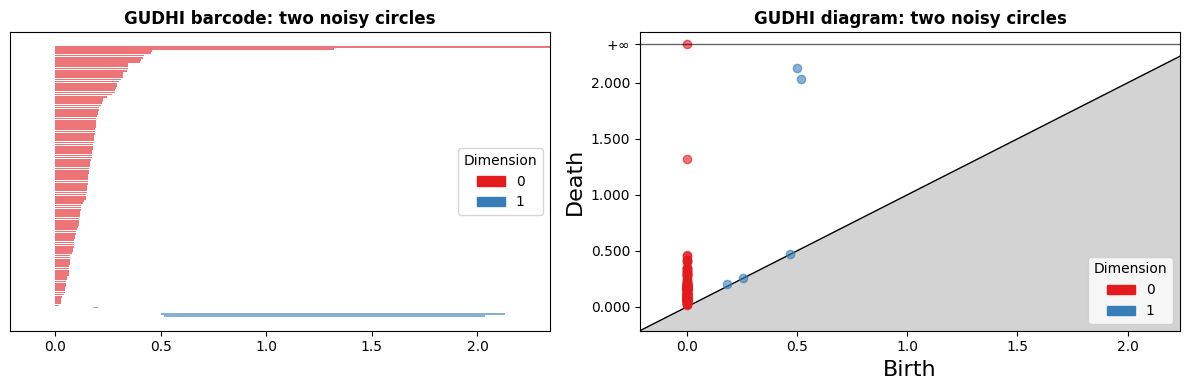

In H1, the student should look for two long-lived generators.


In [24]:
# Barcode point of view: two noisy circles
rips_two = gd.RipsComplex(points=cloud_two_circles, max_edge_length=2.5)
st_two = rips_two.create_simplex_tree(max_dimension=2)
persistence_two = st_two.persistence()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gd.plot_persistence_barcode(persistence_two, axes=axes[0])
axes[0].set_title("GUDHI barcode: two noisy circles", fontweight="bold")
gd.plot_persistence_diagram(persistence_two, axes=axes[1])
axes[1].set_title("GUDHI diagram: two noisy circles", fontweight="bold")
plt.tight_layout()
plt.show()

print("In H1, the student should look for two long-lived generators.")

In [25]:
# A small helper table summarizing what the diagrams suggest
summary_rows = []
for title, dgms in ripser_results.items():
    summary_rows.append([
        title,
        count_long_features(dgms[0], min_persistence=0.35),
        count_long_features(dgms[1], min_persistence=0.35),
    ])

print("Dataset              | long H0 | long H1 | likely shape")
print("-" * 62)
for title, h0_count, h1_count in summary_rows:
    if h1_count >= 2:
        guess = "two loops"
    elif h1_count == 1:
        guess = "one loop"
    else:
        guess = "mostly disconnected clusters / no dominant loop"
    print(f"{title:20s} | {h0_count:7d} | {h1_count:7d} | {guess}")

Dataset              | long H0 | long H1 | likely shape
--------------------------------------------------------------
Three clusters       |      18 |       0 | mostly disconnected clusters / no dominant loop
One noisy circle     |       3 |       1 | one loop
Two noisy circles    |       7 |       2 | two loops


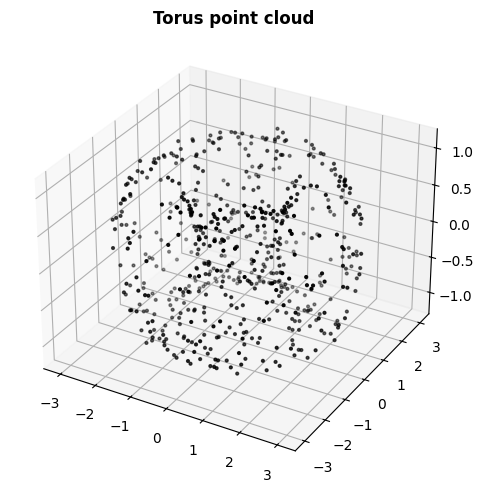

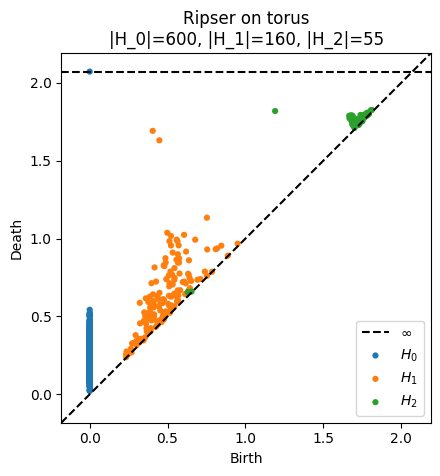

The torus should exhibit nontrivial H1 and H2 information.


In [26]:
# Optional 3D example: torus-like point cloud and H1/H2 hints
np.random.seed(7)
torus_data = tadasets.torus(n=600, c=2, a=1, noise=0.05)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(torus_data[:, 0], torus_data[:, 1], torus_data[:, 2], s=4, c="black")
ax.set_title("Torus point cloud", fontweight="bold")
plt.tight_layout()
plt.show()

torus_dgms = ripser(torus_data, maxdim=2)["dgms"]
plot_diagrams(torus_dgms, show=True, title=f"Ripser on torus\n{diagram_sizes(torus_dgms)}")

print("The torus should exhibit nontrivial H1 and H2 information.")

## Summary and Key Takeaways

### What We Learned

1. **Persistent homology** tracks how topological features appear and disappear across a filtration.
2. **Persistence diagrams** encode each feature as a point $(b, d)$.
3. **Persistence barcodes** encode the same information as intervals $[b, d)$.
4. **$H_0$** is useful for detecting connected components and clusters.
5. **$H_1$** is useful for detecting loops such as circles or multiple circles.
6. **Gudhi**, **Ripser**, and **Giotto-TDA** compute similar topological summaries from different interfaces.

### Practical interpretation

- Many persistent **$H_0$** classes: disconnected groups of points
- One persistent **$H_1$** class: one dominant loop
- Two persistent **$H_1$** classes: two dominant loops
- Points very near the diagonal: likely noise

### Important warning

Persistent homology is a strong exploratory tool, but interpretation depends on:
- sampling density
- noise level
- filtration choice
- scale range

So persistence diagrams should be read as **evidence about shape**, not as a blind automatic decision rule.

## Exercises for Students

### Exercise 1: Diagram Reading
For the three point clouds used in this notebook, identify:
- the number of long-lived $H_0$ classes
- the number of long-lived $H_1$ classes
- the most likely underlying shape

### Exercise 2: Gudhi vs Ripser
Use the same point cloud and compute its persistence diagram with both Gudhi and Ripser.
- Are the dominant topological features the same?
- Which library is easier to interpret for you?

### Exercise 3: Giotto-TDA Batch Processing
Create three new datasets with `tadasets` and process them together with `VietorisRipsPersistence`.
Try to include:
- one dataset with no visible loop
- one dataset with one loop
- one dataset with more than one loop

### Exercise 4: Noise Sensitivity
Take the noisy circle example and gradually increase the noise.
- What happens to the longest $H_1$ bar?
- At what point does the loop become difficult to identify?

### Exercise 5: Your Own Example
Open one of the interactive links at the top of the notebook and then generate your own point cloud inspired by that example. Compute its barcode and persistence diagram, and explain what topological information you can infer.

### Further reading

- Gudhi documentation: https://gudhi.inria.fr/python/latest/
- Ripser / Scikit-TDA: https://ripser.scikit-tda.org/en/latest/
- Giotto-TDA documentation: https://giotto-ai.github.io/gtda-docs/latest/

---

The goal is not only to compute a diagram, but to learn how to read it as a summary of the geometry and topology of the data.